In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
train_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v2_window60.csv"

test_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/test_dataset_v2_window60.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.shape)
print(test_df.shape)

(242965, 87)
(66060, 87)


In [3]:
print(train_df.info())

print(test_df.info())

print(train_df.isnull().sum().sum())

print(test_df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242965 entries, 0 to 242964
Data columns (total 87 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   acc_resultant_mean       242965 non-null  float64
 1   acc_resultant_std        242965 non-null  float64
 2   acc_resultant_variance   242965 non-null  float64
 3   acc_resultant_min        242965 non-null  float64
 4   acc_resultant_max        242965 non-null  float64
 5   acc_resultant_median     242965 non-null  float64
 6   acc_resultant_rms        242965 non-null  float64
 7   acc_resultant_skewness   242965 non-null  float64
 8   acc_resultant_kurtosis   242965 non-null  float64
 9   acc_resultant_q25        242965 non-null  float64
 10  acc_resultant_q75        242965 non-null  float64
 11  acc_resultant_iqr        242965 non-null  float64
 12  acc_horizontal_mean      242965 non-null  float64
 13  acc_horizontal_std       242965 non-null  float64
 14  acc_

In [4]:
target_column = "behavior"

feature_columns = [
    col for col in train_df.columns
    if col not in [
        "behavior",
        "driver",
        "road_type"
    ]
]

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]

y_train = train_df[target_column]
y_test = test_df[target_column]

print(X_train.shape)
print(X_test.shape)

(242965, 84)
(66060, 84)


In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [8]:
rf_pred = rf_model.predict(X_test)

rf_pred[:10]

array([0, 0, 2, 2, 2, 2, 2, 2, 2, 2])

In [9]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.4654


In [10]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.67      0.64      0.65     15257
      DROWSY       0.69      0.30      0.42     36143
      NORMAL       0.29      0.70      0.41     14660

    accuracy                           0.47     66060
   macro avg       0.55      0.55      0.49     66060
weighted avg       0.60      0.47      0.47     66060



<Figure size 700x700 with 0 Axes>

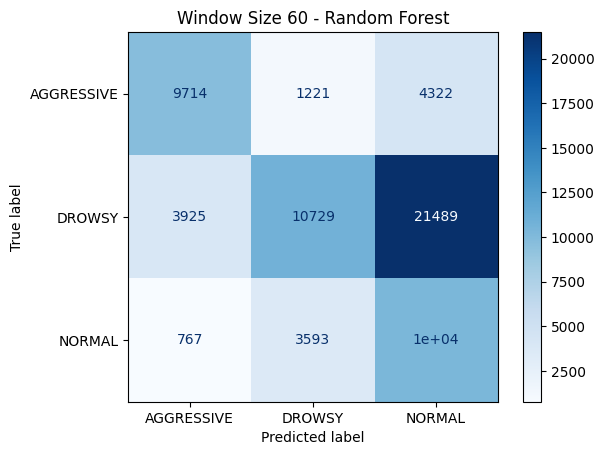

In [11]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(7,7))

disp.plot(cmap="Blues")

plt.title("Window Size 60 - Random Forest")

plt.show()

In [12]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
30,speed_rms,0.039268
28,speed_max,0.039142
82,yaw_q75,0.037463
34,speed_q75,0.037274
76,yaw_max,0.036979
75,yaw_min,0.036094
78,yaw_rms,0.035409
77,yaw_median,0.034730
72,yaw_mean,0.034410
81,yaw_q25,0.033782


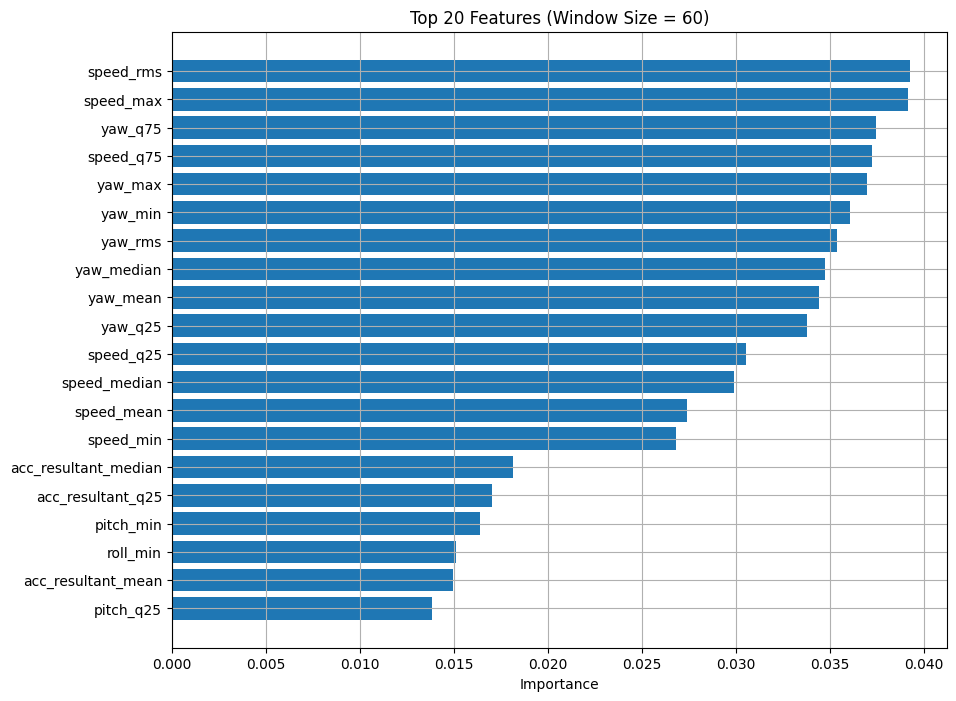

In [13]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]
)

plt.title("Top 20 Features (Window Size = 60)")
plt.xlabel("Importance")
plt.grid(True)

plt.show()